In [5]:
from shinka.utils import load_programs_to_df

path = "results/results_circle_async_large/"
programs_df, prompts_df = load_programs_to_df(path, include_prompts=True)

Total program rows: 100
Correct program rows: 52
Total cost: $1.69
Avg cost per program: $0.02
SQLite error while loading prompts from results/results_circle_async_large/prompts.sqlite: no such table: system_prompts


In [6]:
programs_df.head()

,id,code,language,parent_id,archive_inspiration_ids,top_k_inspiration_ids,generation,timestamp,complexity,embedding,...,meta_recommendations,meta_summary,meta_scratch_pad,_spawned_island,_spawned_from_program_id,_spawn_island_idx,_spawn_strategy,max_tokens,thinking_budget,total_cost
0,18dbe826-79c1-4d3d-b0fd-2ddafb6e22e8,"# EVOLVE-BLOCK-START\n""""""Constructor-based cir...",python,None,[],[],0,2026-03-23 14:43:21.719609976,0.986,"[0.01934814453125, -0.0240631103515625, 0.0655...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000017
1,cf92e3db-405d-43fa-93a6-dbba044cba8b,"# EVOLVE-BLOCK-START\n""""""Constructor-based cir...",python,18dbe826-79c1-4d3d-b0fd-2ddafb6e22e8,[],[],3,2026-03-23 14:43:37.489335060,0.612,"[0.033905029296875, -0.03363037109375, 0.06365...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010737
2,75528b20-0ae5-4d0c-a279-dc3f7e757921,"# EVOLVE-BLOCK-START\n""""""Constructor-based cir...",python,18dbe826-79c1-4d3d-b0fd-2ddafb6e22e8,[],[],18,2026-03-23 14:43:38.704751968,1.000,"[0.025423126, -0.02756806, 0.066786505, -0.022...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010067
3,c719f9e6-c2d2-4301-ac8a-d85acba53c81,"# EVOLVE-BLOCK-START\n""""""Constructor-based cir...",python,18dbe826-79c1-4d3d-b0fd-2ddafb6e22e8,[],[],19,2026-03-23 14:43:49.366875887,1.000,"[0.0179443359375, -0.01458740234375, 0.0725708...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004985
4,f2353ef0-4fbe-402d-bad3-fe588c7d6a2c,"# EVOLVE-BLOCK-START\n""""""Constructor-based cir...",python,18dbe826-79c1-4d3d-b0fd-2ddafb6e22e8,[],[],2,2026-03-23 14:44:01.075999022,1.000,"[0.0157623291015625, -0.03289794921875, 0.0656...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.028637


Filtered to 52 'correct' rows from 100 total.


/Users/rob/Dropbox/Mac (2)/Desktop/ShinkaEvolve/shinka/plots/plot_lineage_tree.py:384: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/rob/anaconda3/envs/scevo/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:457: UserWarning: You passed a edgecolor/edgecolors ('darkred') for an unfilled marker (np.str_('x')).  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  node_collection = ax.scatter(


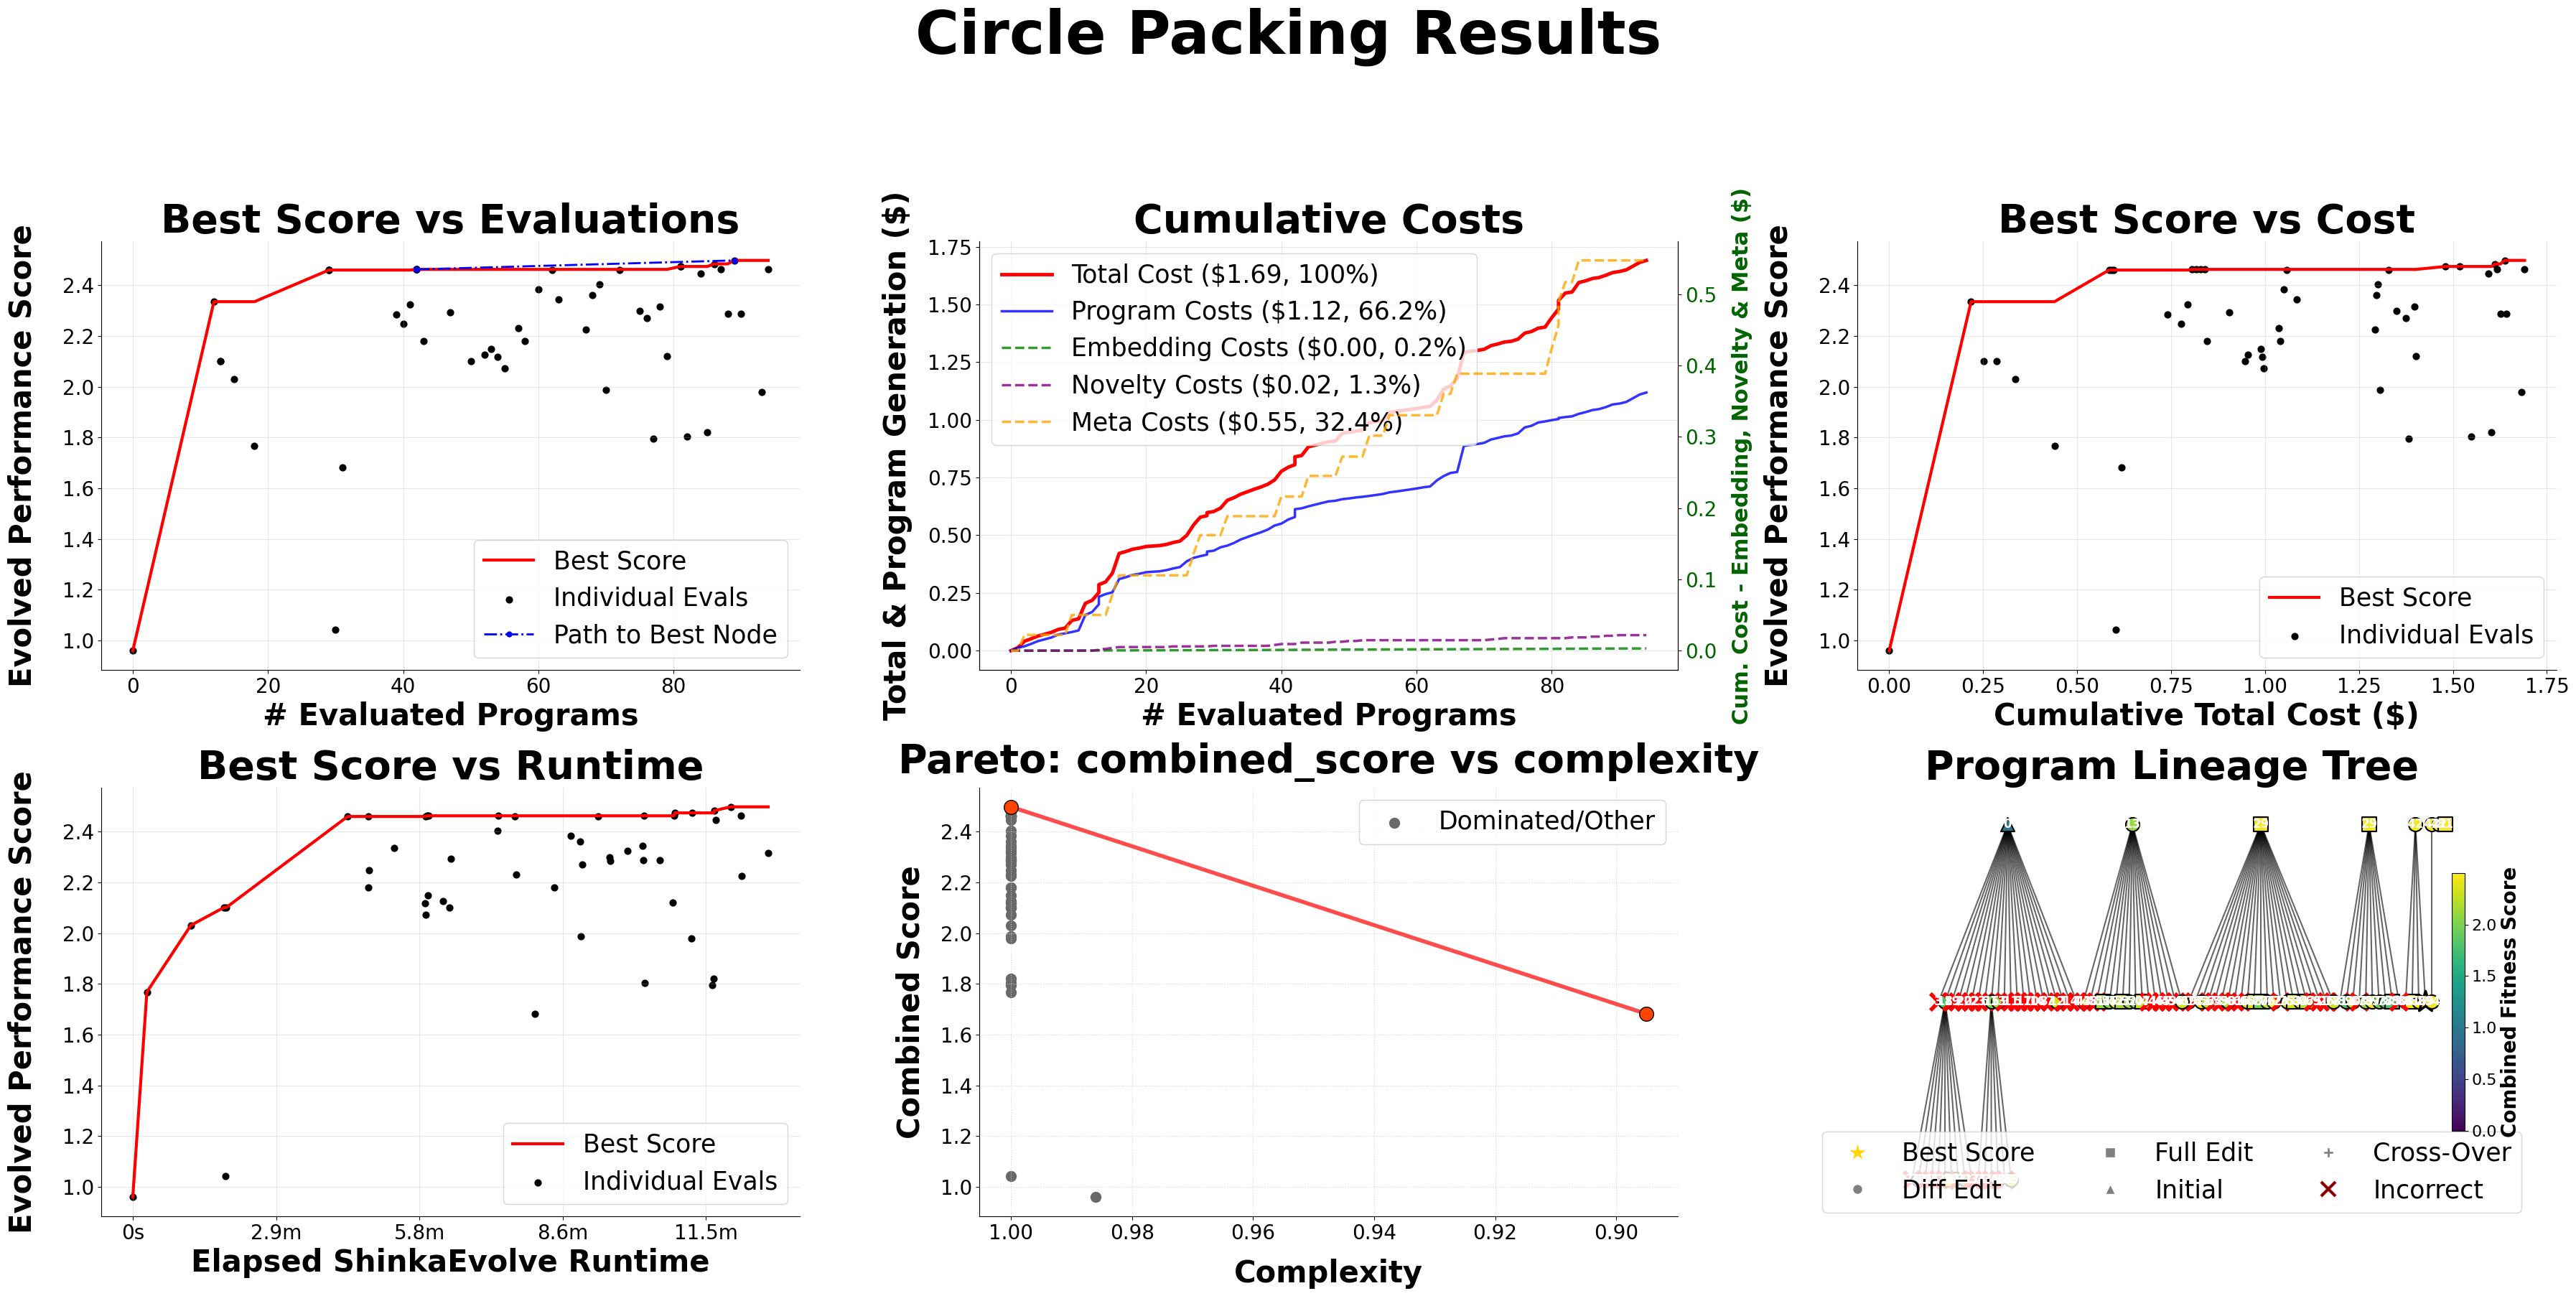

In [7]:
import matplotlib.pyplot as plt

from shinka.plots import plot_evals_performance
from shinka.plots import plot_costs
from shinka.plots import plot_cost_performance
from shinka.plots import plot_time_performance
from shinka.plots import plot_pareto_curve
from shinka.plots import plot_lineage_tree

if programs_df is None or programs_df.empty:
    raise ValueError(
        "No program data loaded. Update `path` in cell 0 to a valid results directory."
    )

fig, axs = plt.subplots(2, 3, figsize=(36, 20))
fig.suptitle("Circle Packing Results", fontsize=60, weight="bold", y=1.02)

plot_evals_performance(
    programs_df,
    title="Best Score vs Evaluations",
    fig=fig,
    ax=axs[0, 0],
    annotate=False,
    show_cost=False,
)

plot_costs(
    programs_df,
    title="Cumulative Costs",
    fig=fig,
    ax=axs[0, 1],
)

plot_cost_performance(
    programs_df,
    title="Best Score vs Cost",
    fig=fig,
    ax=axs[0, 2],
)

plot_time_performance(
    programs_df,
    title="Best Score vs Runtime",
    fig=fig,
    ax=axs[1, 0],
)

# Pick a Pareto pair that usually exists in Shinka results.
if "loc" in programs_df.columns:
    pareto_x, pareto_y = "loc", "combined_score"
    x_maximize, y_maximize = False, True
elif "complexity" in programs_df.columns:
    pareto_x, pareto_y = "complexity", "combined_score"
    x_maximize, y_maximize = False, True
elif "total_cost" in programs_df.columns:
    pareto_x, pareto_y = "total_cost", "combined_score"
    x_maximize, y_maximize = False, True
else:
    pareto_x, pareto_y = "generation", "combined_score"
    x_maximize, y_maximize = True, True

plot_pareto_curve(
    programs_df,
    x_variable=pareto_x,
    y_variable=pareto_y,
    x_maximize=x_maximize,
    y_maximize=y_maximize,
    title=f"Pareto: {pareto_y} vs {pareto_x}",
    fig=fig,
    ax=axs[1, 1],
    annotate=False,
)

plot_lineage_tree(
    programs_df,
    title="Program Lineage Tree",
    fig=fig,
    ax=axs[1, 2],
)

fig.tight_layout(rect=(0, 0.12, 1, 0.94))
plt.show()


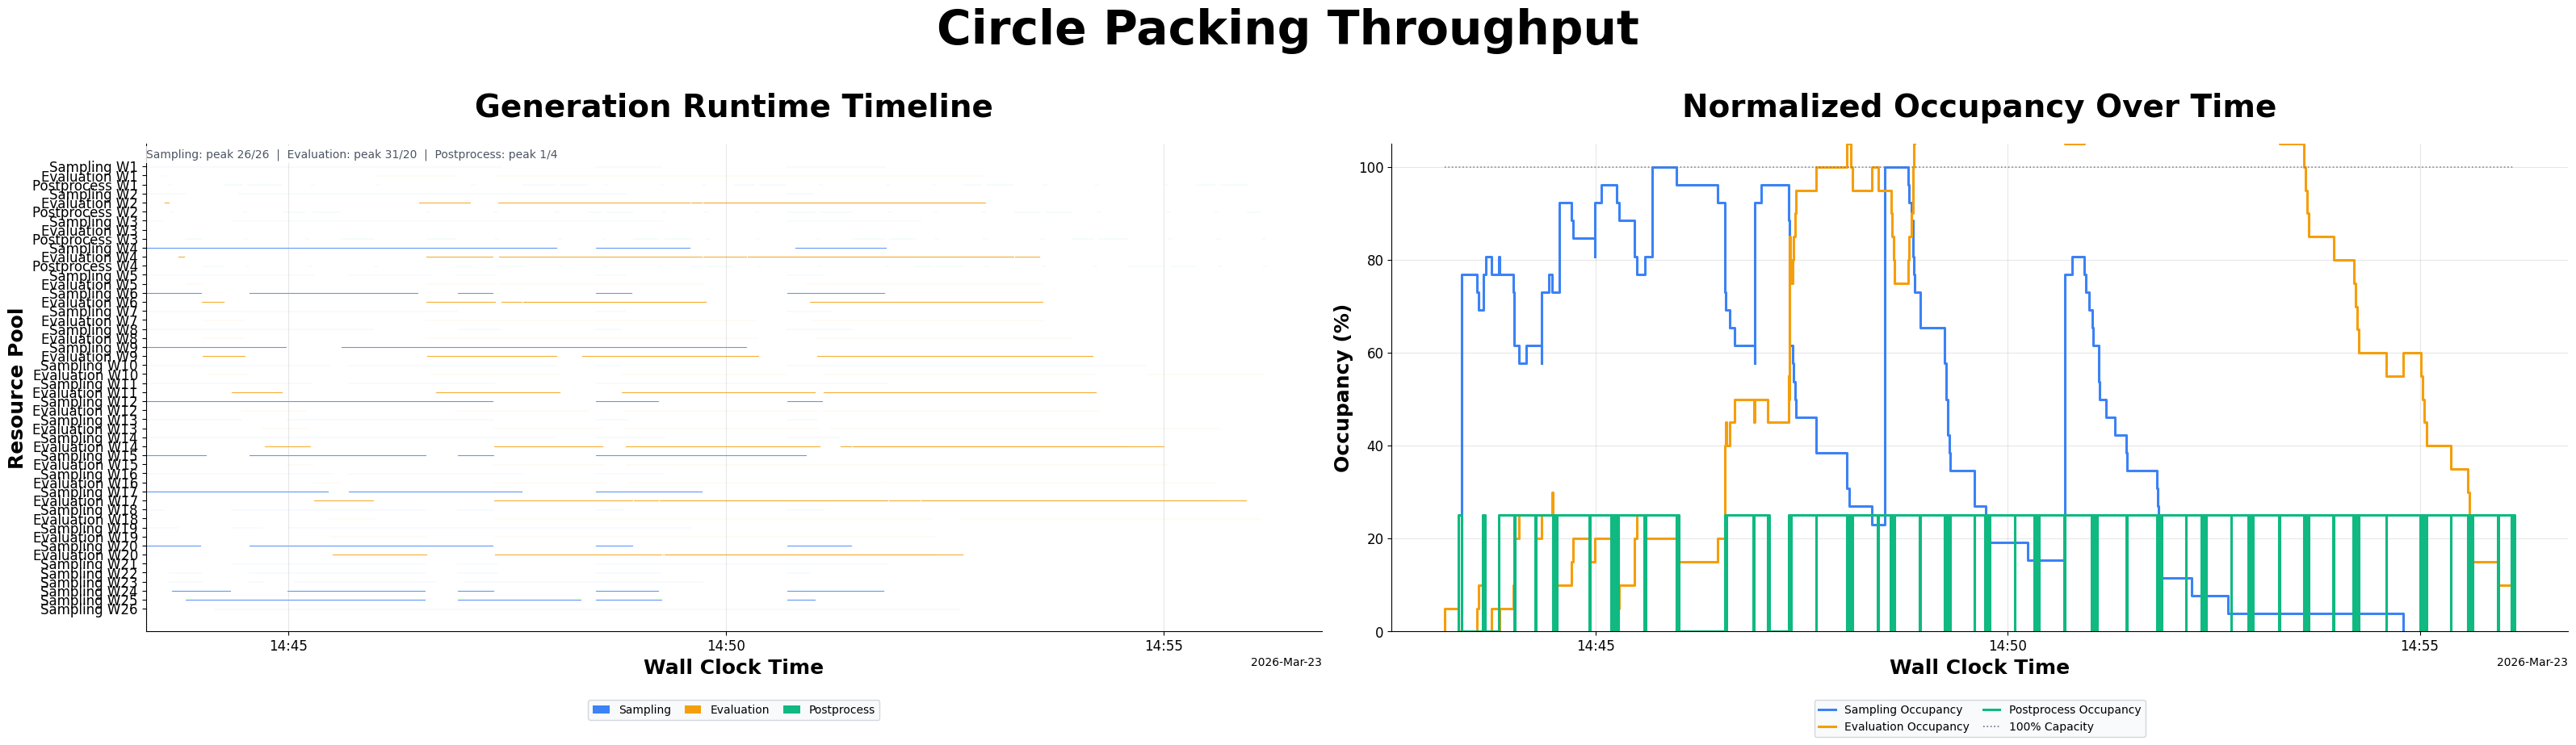

In [8]:
from shinka.plots import plot_generation_runtime_timeline
from shinka.plots import plot_normalized_occupancy_over_time

fig, axs = plt.subplots(1, 2, figsize=(32, 9))
fig.suptitle("Circle Packing Throughput", fontsize=42, weight="bold", y=1.02)

plot_generation_runtime_timeline(
    programs_df,
    title="Generation Runtime Timeline",
    fig=fig,
    ax=axs[0],
)

plot_normalized_occupancy_over_time(
    programs_df,
    title="Normalized Occupancy Over Time",
    fig=fig,
    ax=axs[1],
)

plt.tight_layout()
plt.show()
